# Eda analysis for covid19 datasets :

I have chosen datasets 'wearables.csv', 'surveys.csv', 'sleep.csv', 'participants.csv'. in order to check the activity done and sleep cycles of participants and to see how it corresponds to the symptoms that people are experiencing 

The question i aim to answer is :"Is there a correlation between these different types of data?"

2. Time-Series Analysis

As the data contains time-stamped information,

Daily Trends: Plot daily values for metrics like resting_pulse or steps_count to see how they change for individual users.

Event-Based Analysis: Since we have a symptoms_onset column, we can analyze physiological changes before and after symptom onset. For example, does a user's resting_pulse or body_temperature_avg trend upward in the days leading up to reporting symptoms?

3. Group Comparisons

Using categorical data to compare different groups within participant base.

Demographic Analysis: Compare metrics across different gender or age_range groups. Do people in a certain age group take more steps, or is their average sleep duration different?

Geographical Analysis: Compare health and activity metrics between different city or country groups to see if there are any regional differences.

In [30]:
# initial data pull and merge

import pandas as pd
from functools import reduce
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

csv_files = ['wearables.csv', 'surveys.csv', 'sleep.csv', 'participants.csv']

# Read all CSV files into a list of dataframes
dfs = [pd.read_csv(f) for f in csv_files]

# Merge the dataframes sequentially using reduce
# The 'how' parameter specifies the type of join.
# 'outer' includes all usercodes from all files, filling missing data with NaN.
# 'inner' would only include usercodes present in all files.
df = reduce(lambda left, right: pd.merge(left, right, on='user_code', how='inner'), dfs)
pd.DataFrame(df).to_csv('datafinal.csv', index=False)

print(df)

KeyboardInterrupt: 

# Initial data check :
the dimensions of the dataset (number of rows and columns)?
the data types of the variables (numerical, categorical, text, etc.)?
Are there any missing values ?

In [ ]:
#eda step one: data check

print("Data Structure")
print("---------------")
print(f"Dimensions: {df.shape}")
print(f"Data Types:\n{df.dtypes}")
print(f"Missing Values:\n{df.isnull().sum()}")


Data Structure
---------------
Dimensions: (2649250, 40)
Data Types:
user_code                           object
day_x                               object
resting_pulse                      float64
pulse_average_x                    float64
pulse_min_x                        float64
pulse_max_x                        float64
average_spo2_value                 float64
body_temperature_avg               float64
stand_hours_total                  float64
steps_count                        float64
distance                           float64
steps_speed                        float64
total_number_of_flights_climbed    float64
active_calories_burned             float64
basal_calories_burned              float64
total_calories_burned              float64
average_headphone_exposure         float64
average_environment_exposure       float64
scale                               object
created_at                          object
value                                int64
text                        

# Interpretation and Rectifying and cleaning the data based on these observations


Nearly Complete Data (0% Missing): user_code, day_x, scale, created_at, value, text, day_y, sleep_begin, sleep_end, sleep_duration, basal_calories_burned, total_calories_burned, gender, age_range, city, country, height, and weight have no missing values.

Columns with Less than 50% Missing Data:

resting_pulse: 4.53%

pulse_average_x, pulse_min_x, pulse_max_x: 2.33% each

symptoms_onset: 10.64%

total_number_of_flights_climbed: 19.50%

distance: 21.38%

steps_count: 21.98%

active_calories_burned: 24.24%

steps_speed: 32.06%

These columns with less that 35% missing data will be imputed with a median value.

average_environment_exposure: 51.85%

stand_hours_total: 60.35%

body_temperature_avg: 66.35%

'body_temperature_avg', 'stand_hours_total', 'average_environment_exposure' : will be left as Nan as imputation is not recommended due to a high missing rate

Columns with High Percentage of Missing Data (>50%):

average_spo2_value: 82.40%

average_headphone_exposure: 94.72%

sleep_awake_duration: 99.04%

sleep_rem_duration: 99.20%

sleep_light_duration: 98.23%

sleep_deep_duration: 98.63%

pulse_min_y, pulse_max_y, pulse_average_y: 99.24% each

Going to drop columns with high percent of missing data


In [ ]:
columns_to_drop = [
    'average_headphone_exposure',
    'sleep_awake_duration',
    'sleep_rem_duration',
    'sleep_light_duration',
    'sleep_deep_duration',
    'pulse_min_y',
    'pulse_max_y',
    'pulse_average_y',
    'average_spo2_value'
]

df.drop(columns=columns_to_drop, inplace=True)

# 2. Define columns for median imputation
columns_for_median_imputation = [
    'resting_pulse',
    'pulse_average_x',
    'pulse_min_x',
    'pulse_max_x',
    'steps_count',
    'distance',
    'steps_speed',
    'total_number_of_flights_climbed',
    'active_calories_burned',
    'basal_calories_burned',
    'total_calories_burned'
]

# Perform median imputation
for column in columns_for_median_imputation:
    median_value = df[column].median()
    df.fillna({column:median_value}, inplace=True)

# 3. Handle 'symptoms_onset' by filling with a new category
# A missing value here likely means no symptoms were reported.
df.fillna({'symptoms_onset':'Not Reported'}, inplace=True)

# 4. For columns with high missing rates, leave them as they are (NaN)
# This includes 'body_temperature_avg', 'stand_hours_total', 'average_environment_exposure'
# No action is needed for these as the previous steps have already created the desired result.


print(df.info())

print("Data Structure")
print("---------------")
print(f"Dimensions: {df.shape}")
print(f"Data Types:\n{df.dtypes}")
print(f"Missing Values:\n{df.isnull().sum()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2649250 entries, 0 to 2649249
Data columns (total 31 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   user_code                        object 
 1   day_x                            object 
 2   resting_pulse                    float64
 3   pulse_average_x                  float64
 4   pulse_min_x                      float64
 5   pulse_max_x                      float64
 6   body_temperature_avg             float64
 7   stand_hours_total                float64
 8   steps_count                      float64
 9   distance                         float64
 10  steps_speed                      float64
 11  total_number_of_flights_climbed  float64
 12  active_calories_burned           float64
 13  basal_calories_burned            float64
 14  total_calories_burned            float64
 15  average_environment_exposure     float64
 16  scale                            object 
 17  created_

# Objective

What are the central tendency measures (mean, median, mode) for numerical variables?
What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
What is the distribution of the variables (normal, skewed, etc.)?

In [ ]:
# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = df.select_dtypes(include=[np.number]).columns
print ("Numeric Columns:", numeric_columns.tolist())
print("Central Tendency Measures:")
print(df[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(df[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(df[numeric_columns].skew())
print(df[numeric_columns].kurt())


Descriptive Statistics
----------------------
Numeric Columns: ['resting_pulse', 'pulse_average_x', 'pulse_min_x', 'pulse_max_x', 'body_temperature_avg', 'stand_hours_total', 'steps_count', 'distance', 'steps_speed', 'total_number_of_flights_climbed', 'active_calories_burned', 'basal_calories_burned', 'total_calories_burned', 'average_environment_exposure', 'value', 'sleep_duration', 'height', 'weight']
Central Tendency Measures:
      resting_pulse  pulse_average_x  pulse_min_x  pulse_max_x  \
mean      49.856247        70.349632    47.492222   112.633878   
50%       49.000000        67.000000    46.000000   111.000000   

      body_temperature_avg  stand_hours_total  steps_count     distance  \
mean             36.404615          10.853724  7265.100897  4910.750045   
50%              36.400000          12.000000  6858.000000  4532.000000   

      steps_speed  total_number_of_flights_climbed  active_calories_burned  \
mean    22.321117                        26.102866            

# Interpretation of Descriptive Statistics

Central Tendency:

The mean and median provide insight into the typical values for each metric. For many metrics, the mean and median are close, indicating a fairly balanced distribution. For example, the mean resting_pulse is 49.86 and the median is 49.0, which are very similar. 

However, there are some noticeable differences, such as for steps_count (mean: 7265, median: 6858) and active_calories_burned (mean: 180, median: 80). The significant difference between the mean and median for active_calories_burned suggests that the data may be skewed or that there are some very high values influencing the mean.

Dispersion Measures:

These metrics reveal how spread out the data is. The standard deviation is a key indicator here. A higher standard deviation indicates greater variability in the data.

 For instance, the pulse_max_x has a high standard deviation (27.12), indicating a wide range of maximum pulse rates among participants. The steps_count also shows a large standard deviation (4081), meaning that the number of steps taken varies widely. The min and max values show the full range of the data for each feature.

Distribution Measures:
These measures help to understand the shape of the data's distribution.

Skewness:

Right-Skewed (positive skewness): A positive skewness value indicates a long tail to the right, meaning there are some unusually high values. This is particularly evident for resting_pulse (3.57), steps_count (0.79), and active_calories_burned (4.39). The high skewness for active_calories_burned supports the earlier observation that the mean is significantly higher than the median, likely due to a few very active participants.

Symmetric (near zero): value has a skewness of 0.06, which suggests its distribution is nearly symmetric.

In [ ]:
# Data Quality
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {df.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(df.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
                                 most_frequent_value
user_code                                 6be5033971
day_x                                     2020-03-11
resting_pulse                                   50.0
pulse_average_x                                 64.0
pulse_min_x                                     47.0
pulse_max_x                                     88.0
body_temperature_avg                            36.6
stand_hours_total                               10.0
steps_count                                   6858.0
distance                                      4532.0
steps_speed                                     22.0
total_number_of_flights_climbed                 22.0
active_calories_burned                          80.0
basal_calories_burned                         1761.0
total_calories_burned                         1765.0
average_environment_exposure                   56.67
scale              

# Interpretation
Duplicated Rows: There are no duplicated rows in the dataset.

Inconsistent Values: Most frequent values for each column. This helps identify any potential inconsistencies or anomalies. for example we have most data coming in on date " 2020-03-11" and  user "6be5033971" is the msot frequent user value.It might indicate an issue with data collection or entry or that just most data was collected on a particular day and one particular person wore the device for a little longer.

# Objective

Find correlation between pairs of numerical variables.
Are there any noticeable patterns or trends in the data?
How are categorical variables related to numerical variables?


Variable Relationships
----------------------
Correlation Matrix:
                                 resting_pulse  pulse_average_x  pulse_min_x  \
resting_pulse                         1.000000         0.233008     0.604987   
pulse_average_x                       0.233008         1.000000     0.190315   
pulse_min_x                           0.604987         0.190315     1.000000   
pulse_max_x                          -0.060881         0.578498    -0.218475   
body_temperature_avg                 -0.156849        -0.020216     0.020183   
stand_hours_total                    -0.171450         0.280994    -0.137535   
steps_count                          -0.091154         0.315276    -0.072481   
distance                             -0.082335         0.250547    -0.053648   
steps_speed                           0.050238         0.062612    -0.011667   
total_number_of_flights_climbed      -0.063434         0.202609    -0.038823   
active_calories_burned                0.390418       

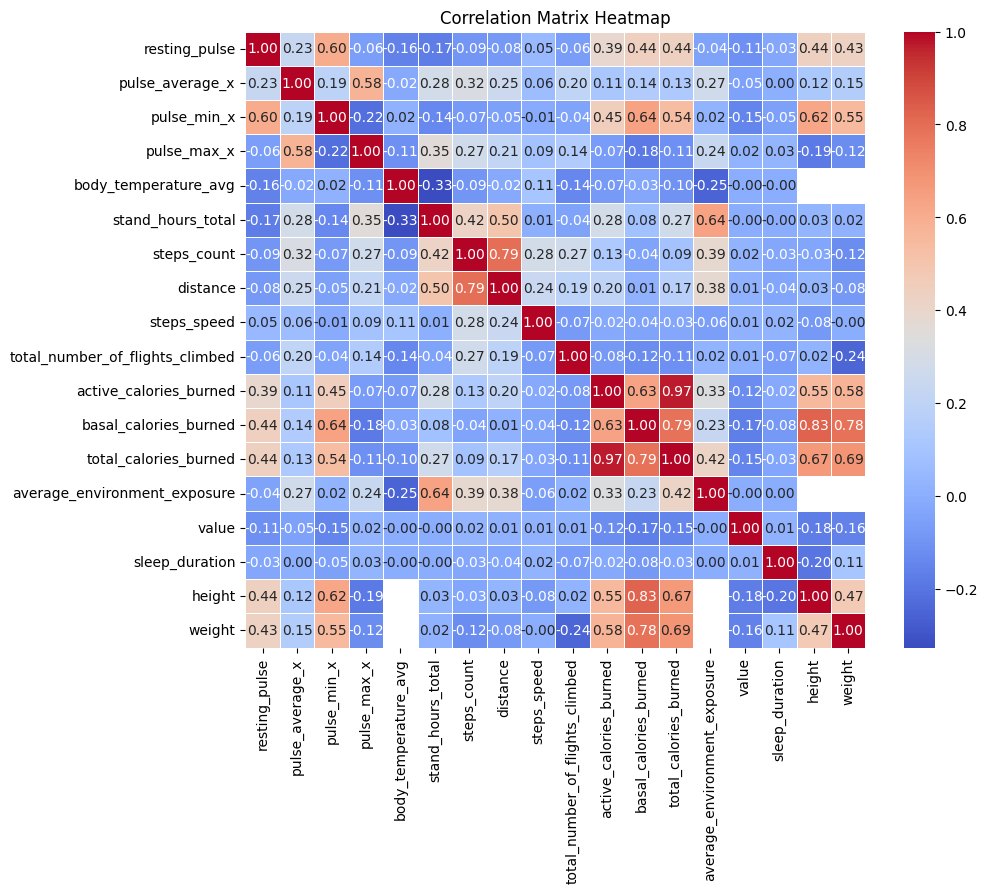

In [ ]:
# Variable Relationships
print("\nVariable Relationships")
print("----------------------")
print("Correlation Matrix:")
correlation_matrix = df[numeric_columns].corr()
print(correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Interpretation:  Key Relationships in  Data

Physiological Metrics: resting_pulse has a strong positive correlation with pulse_min_x (0.60), and a moderate positive correlation with basal_calories_burned (0.44) and height (0.43). This suggests that people with higher resting pulses tend to have higher basal calorie expenditure and are generally taller.

Activity Metrics: As expected, steps_count and distance have a very strong positive correlation (0.79), which makes perfect sense as more steps directly lead to more distance covered. Similarly, total_calories_burned has a very strong positive correlation with active_calories_burned (0.97), and a strong positive correlation with basal_calories_burned (0.79). This indicates that the total calories burned is a combination of both active and basal expenditure.

Physical Demographics: There are strong positive correlations between height, weight, basal_calories_burned and active_calories_burned. For example, height and basal_calories_burned have a high correlation (0.83), meaning taller people tend to have a higher basal metabolic rate. Similarly, weight and basal_calories_burned have a strong correlation (0.78).

The matrix confirms expected relationships, such as those between activity metrics and physical demographics

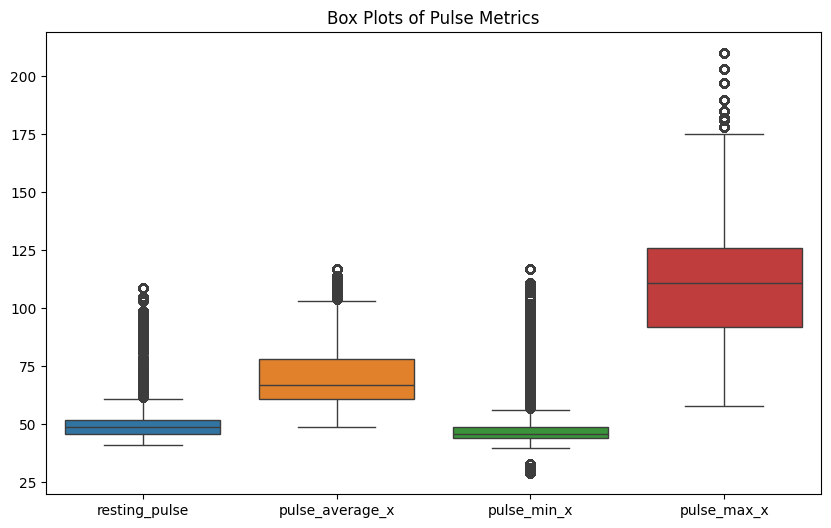

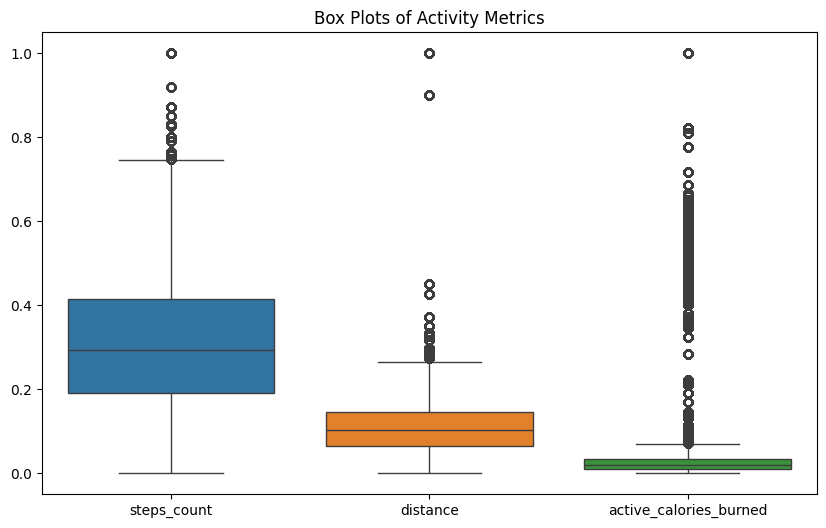

In [ ]:
# Data Visualization
numeric_columns = ['resting_pulse', 'steps_count', 'distance', 'total_number_of_flights_climbed', 'total_calories_burned', 'sleep_duration', 'height', 'weight']
df_sampled = df.sample(n=5000, random_state=42)

# Now, run the pair plot on the smaller dataset
sns.pairplot(df_sampled, vars=numeric_columns, hue='age_range', diag_kind='kde')

# Add a title to the plot
plt.suptitle(f'Pair Plot of Key Metrics by Age Range', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])

# Display the plot
plt.show()

# Visualize distributions
numeric_columns = ['resting_pulse', 'body_temperature_avg', 'stand_hours_total', 'steps_count', 'distance', 'steps_speed', 'total_number_of_flights_climbed', 'total_calories_burned', 'average_environment_exposure', 'sleep_duration', 'height', 'weight']
df[numeric_columns].hist(bins=20, figsize=(15, 12), grid=False)
plt.suptitle('Histograms of Numeric Features', y=0.95, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Box plots to identify outliers
# Grouping variables by similar scales
pulse_metrics = ['resting_pulse', 'pulse_average_x', 'pulse_min_x', 'pulse_max_x']
activity_metrics = ['steps_count', 'distance', 'active_calories_burned']

# Plot the pulse metrics together
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[pulse_metrics])
plt.title('Box Plots of Pulse Metrics')
plt.show()

# Plot the activity metrics together
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[activity_metrics])
plt.title('Box Plots of Activity Metrics')
plt.show()

# Interpretation 

Pair Plot: 
The pair plot displays the relationships between key metrics like resting_pulse, steps_count, and sleep_duration, with data points colored by age_range

Had to sample the data to reduce the burden on computation

Histograms
The histograms show the frequency distribution for each of your numerical features. we see that most metrics, especially steps_count and active_calories_burned, are highly skewed to the right.

Box Plots
The box plots are particularly useful for identifying outliers. For most activity-related metrics, such as steps_count, distance, and active_calories_burned, the box plots show a small main box with long whiskers and many individual data points plotted far from the rest of the data. This visually confirms the presence of significant outliers and the skewed distributions seen in the histograms.

# Feature engineering

Introducing new  feature as "Daily Activity Score" by combining several of existing metrics. 

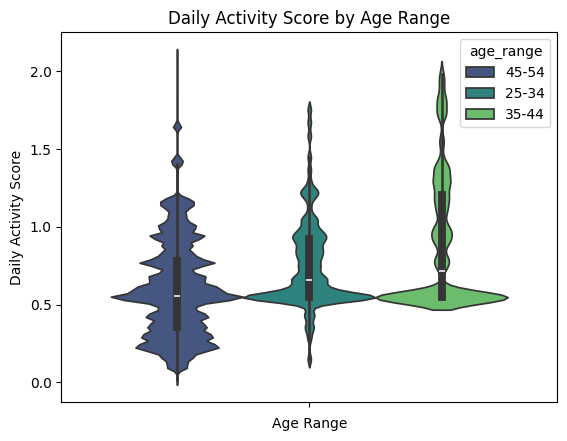

In [ ]:
# Feature Engineering: Daily Activity Score

activity_metrics = ['steps_count', 'distance', 'total_number_of_flights_climbed', 'active_calories_burned']

# Handle any potential remaining missing values in these specific columns by filling with the median
# This is a crucial step before scaling to prevent errors
for col in activity_metrics:
    df.fillna({col:df[col].median()}, inplace=True)

# 2. Initialize the Min-Max Scaler
scaler = MinMaxScaler()

# 3. Fit and transform the selected columns
# The scaler is applied to only the activity metrics
df[activity_metrics] = scaler.fit_transform(df[activity_metrics])

# 4. Create the new feature by summing the normalized columns
# We add a small constant (e.g., 0.001) to handle cases where all values are zero, to avoid a score of zero.
df['daily_activity_score'] = df[activity_metrics].sum(axis=1)

# Visualize new features
sns.violinplot(hue='age_range', y='daily_activity_score', data=df, palette='viridis')
plt.title('Daily Activity Score by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Daily Activity Score')
plt.show()


# New Features 

This new feature would serve as a single, normalized measure of a participant's daily activity level, making it much easier to analyze and compare than looking at individual metrics.

# Data Profiling

This was a foundational step that acted as a sanity check. It confirmed that the
data was loaded and merged correctly and helped identify which columns require
cleaning or imputation before further analysis.

# Data Completeness

Dropping columns with a high rate of missing data prevented them from skewing analysis. Imputing with the median was a great choice because, as your descriptive stats showed, we were missing lower percentages of data that couldve been approximated by median imputation.

# Data integrity

The result of zero duplicates is a positive sign for data integrity.

# Data Lineage and Provenance

the script explicitly lists the raw CSV files and documents with the exact merging strategy (`inner` join using `reduce`).Anyone ses notebook knows exactly where the data came from and what steps were taken to clean it making it easy to reproduce.